# 고급 데이터 정제

> Phase 2의 기초 정제를 넘어 **유사도 기반 중복 제거와 품질 스코어링**으로 진화

In [2]:
# === 환경 설치 ===
!pip install datasets scikit-learn matplotlib

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -------------------- ------------------- 4.5/8.9 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 23.0 MB/s  0:00:00
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------

In [3]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# === Alpaca 데이터 로드 ===
dataset = load_dataset("tatsu-lab/alpaca", trust_remote_code=True)
train = dataset['train']

# 실습용으로 1000개만 사용
data = train.select(range(1000))
print(f"실습 데이터: {len(data)}개")
print(f"열: {data.column_names}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tatsu-lab/alpaca' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


실습 데이터: 1000개
열: ['instruction', 'input', 'output', 'text']


---
## 1. 형식 검증: 데이터가 올바른 구조인가?

In [12]:
# === 형식 검증: 필수 필드 존재 여부 ===
# 실전에서는 JSON 파싱 실패, 필수 필드 누락이 빈번하다

required_fields = ['instruction', 'output']

def validate_format(sample):
    """필수 필드 존재 여부와 기본 유효성 체크"""
    issues = []
    
    for field in required_fields:
        if field not in sample or sample[field] is None:
            issues.append(f"{field} 누락")
            print(f"{field} 누락")
        elif not isinstance(sample[field], str):
            issues.append(f"{field} 타입 오류")
            print(f"{field} 타입 오류")
        elif len(sample[field].strip()) == 0:
            issues.append(f"{field} 빈값")
            print(f"{field} 빈값")
    
    return len(issues) == 0

# 전체 검증
valid_count = sum(1 for i in range(len(data)) if validate_format(data[i]))
invalid_count = len(data) - valid_count

print(f"형식 검증 결과:")
print(f"  유효: {valid_count}개")
print(f"  무효: {invalid_count}개")

# 무효한 샘플 확인
if invalid_count > 0:
    shown = 0
    for i in range(len(data)):
        if not validate_format(data[i]):
            print(f"  무효 샘플 [{i}]: {data[i]['instruction'][:50]}")
            shown += 1
            if shown >= 3:
                break

output 빈값
형식 검증 결과:
  유효: 999개
  무효: 1개
output 빈값
  무효 샘플 [284]: Standardize the following date to the ISO 8601 for


In [9]:
data

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 1000
})

---
## 2. 기초 필터링 (Phase 2 복습 + 강화)

In [13]:
# === 기초 필터링: 길이 기반 + 빈값 제거 ===
# Phase 2에서 했던 것과 동일하지만, 더 세밀한 기준 적용

before = len(data)

# 1) 빈 instruction이나 output 제거
data_clean = data.filter(lambda x: len(x['instruction'].strip()) > 0)
data_clean = data_clean.filter(lambda x: len(x['output'].strip()) > 0)
after_empty = len(data_clean)

# 2) output이 너무 짧은 샘플 제거 (30자 미만)
data_clean = data_clean.filter(lambda x: len(x['output']) >= 30)
after_short = len(data_clean)

# 3) output이 너무 긴 샘플 제거 (5000자 초과 = 이상치)
data_clean = data_clean.filter(lambda x: len(x['output']) <= 5000)
after_long = len(data_clean)

print(f"기초 필터링 결과:")
print(f"  원본: {before}개")
print(f"  빈값 제거 후: {after_empty}개 (-{before - after_empty})")
print(f"  짧은 샘플 제거 후: {after_short}개 (-{after_empty - after_short})")
print(f"  긴 샘플 제거 후: {after_long}개 (-{after_short - after_long})")

Filter: 100%|██████████| 840/840 [00:00<00:00, 36451.83 examples/s]

기초 필터링 결과:
  원본: 1000개
  빈값 제거 후: 999개 (-1)
  짧은 샘플 제거 후: 840개 (-159)
  긴 샘플 제거 후: 840개 (-0)


---
## 3. TF-IDF 유사도 기반 중복 제거

Phase 2의 exact match는 "Python으로 Hello 출력"과 "파이썬으로 Hello 출력"을 구분 못 함.  
TF-IDF + 코사인 유사도로 **의미적 유사 중복**까지 잡는다.

In [14]:
# === TF-IDF 벡터화 ===
# 각 instruction을 숫자 벡터로 변환하여 유사도 계산 가능하게 만든다

instructions = [data_clean[i]['instruction'] for i in range(len(data_clean))]

# TF-IDF: 단어 빈도 기반으로 텍스트를 벡터화
# Phase 1의 임베딩과 비슷한 역할이지만, 훨씬 단순한 방식
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(instructions)

print(f"TF-IDF 행렬 크기: {tfidf_matrix.shape}")
print(f"  행: {tfidf_matrix.shape[0]}개 instruction")
print(f"  열: {tfidf_matrix.shape[1]}개 어휘 특성")
print(f"\n-> 각 instruction이 {tfidf_matrix.shape[1]}차원 벡터로 표현됨")
print(f"   Phase 1의 임베딩(768차원)과 같은 개념, 더 단순한 방식")

TF-IDF 행렬 크기: (840, 1502)
  행: 840개 instruction
  열: 1502개 어휘 특성

-> 각 instruction이 1502차원 벡터로 표현됨
   Phase 1의 임베딩(768차원)과 같은 개념, 더 단순한 방식


In [15]:
# === 유사도 기반 중복 탐지 ===
# 모든 쌍의 코사인 유사도를 계산하면 O(n^2)이라 느림
# 실전에서는 배치 처리나 근사 방법 사용

# 여기서는 1000개 이하라 직접 계산 가능
sim_matrix = cosine_similarity(tfidf_matrix)

# 유사도 임계값: 0.85 이상이면 중복으로 판정
threshold = 0.85

# 중복 쌍 찾기 (자기 자신 제외, 상삼각만)
duplicates = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i][j] >= threshold:
            duplicates.append((i, j, sim_matrix[i][j]))

print(f"유사도 {threshold} 이상 중복 쌍: {len(duplicates)}개")
print(f"\n상위 5개 중복 쌍:")
for idx, (i, j, sim) in enumerate(sorted(duplicates, key=lambda x: -x[2])[:5]):
    print(f"\n  [{idx+1}] 유사도: {sim:.3f}")
    inst_i = instructions[i][:60]
    inst_j = instructions[j][:60]
    print(f"    A: {inst_i}")
    print(f"    B: {inst_j}")

유사도 0.85 이상 중복 쌍: 3개

상위 5개 중복 쌍:

  [1] 유사도: 0.926
    A: Summarize the article below in 5 sentences.
    B: Summarize the given article in 1-2 sentences.

  [2] 유사도: 0.900
    A: What is the main idea of this text?
    B: Identify the main idea of the text.

  [3] 유사도: 0.890
    A: Write a one-sentence summary of the following news article.
    B: Generate a 1-sentence summary on the following news article.


In [16]:
# === 중복 제거: 유사 쌍 중 하나만 남기기 ===

# 제거할 인덱스 수집 (각 쌍에서 뒤쪽 인덱스를 제거)
to_remove = set()
for i, j, sim in duplicates:
    if i not in to_remove:  # i가 이미 제거 대상이 아니면
        to_remove.add(j)    # j를 제거

# 유지할 인덱스
to_keep = [i for i in range(len(data_clean)) if i not in to_remove]
data_dedup = data_clean.select(to_keep)

print(f"유사도 기반 중복 제거:")
print(f"  제거 전: {len(data_clean)}개")
print(f"  제거 후: {len(data_dedup)}개 (-{len(to_remove)}개)")
print(f"\n-> exact match로는 잡지 못하는 유사 중복까지 제거됨")

유사도 기반 중복 제거:
  제거 전: 840개
  제거 후: 837개 (-3개)

-> exact match로는 잡지 못하는 유사 중복까지 제거됨


---
## 4. 품질 스코어링

In [18]:
# === 품질 스코어 계산 ===
# 단순 필터링(있다/없다)이 아닌 연속적인 점수로 품질 판단

def quality_score(sample):
    """
    4가지 기준으로 0~1 사이의 품질 점수를 계산.
    실전에서는 LLM-as-Judge로 더 정교하게 판단.
    """
    scores = {}
    
    # 1) 길이 적절성 (50~500자가 최적)
    output_len = len(sample['output'])
    if 50 <= output_len <= 500:
        scores['length'] = 1.0
    elif output_len < 50:
        scores['length'] = output_len / 50  # 0~1
    else:
        scores['length'] = max(0, 1 - (output_len - 500) / 2000)
    
    # 2) 어휘 다양성 (고유 단어 / 전체 단어)
    words = sample['output'].split()
    if len(words) > 0:
        scores['diversity'] = len(set(words)) / len(words)
    else:
        scores['diversity'] = 0
    
    # 3) instruction-output 관련성 (단어 겹침 비율)
    inst_words = set(sample['instruction'].lower().split())
    out_words = set(sample['output'].lower().split())
    if len(inst_words) > 0:
        overlap = len(inst_words & out_words) / len(inst_words)
        scores['relevance'] = min(overlap * 2, 1.0)  # 50% 이상 겹치면 만점
    else:
        scores['relevance'] = 0
    
    # 4) 형식 완성도 (줄바꿈, 코드블록 등 구조화 여부)
    has_structure = any(c in sample['output'] for c in ['\n', ':', '-', '1.', '```'])
    scores['structure'] = 0.8 if has_structure else 0.4
    
    # 종합 점수 (가중 평균)
    total = (scores['length'] * 0.25 +
             scores['diversity'] * 0.25 +
             scores['relevance'] * 0.25 +
             scores['structure'] * 0.25)
    
    return total, scores

# 전체 데이터에 스코어 계산
all_scores = []
for i in range(len(data_dedup)):
    total, details = quality_score(data_dedup[i])
    all_scores.append(total)

all_scores = np.array(all_scores)
print(f"품질 스코어 통계:")
print(f"  평균: {all_scores.mean():.3f}")
print(f"  중앙값: {np.median(all_scores):.3f}")
print(f"  최소: {all_scores.min():.3f}")
print(f"  최대: {all_scores.max():.3f}")

# 예시
print(f"\n점수 상세 예시:")
sample_idx = 0
total, details = quality_score(data_dedup[sample_idx])
inst = data_dedup[sample_idx]['instruction'][:50]
print(f"  instruction: {inst}...")
print(f"  종합: {total:.3f}")
for k, v in details.items():
    print(f"    {k}: {v:.3f}")

품질 스코어 통계:
  평균: 0.745
  중앙값: 0.760
  최소: 0.468
  최대: 0.950

점수 상세 예시:
  instruction: Give three tips for staying healthy....
  종합: 0.656
    length: 1.000
    diversity: 0.824
    relevance: 0.000
    structure: 0.800


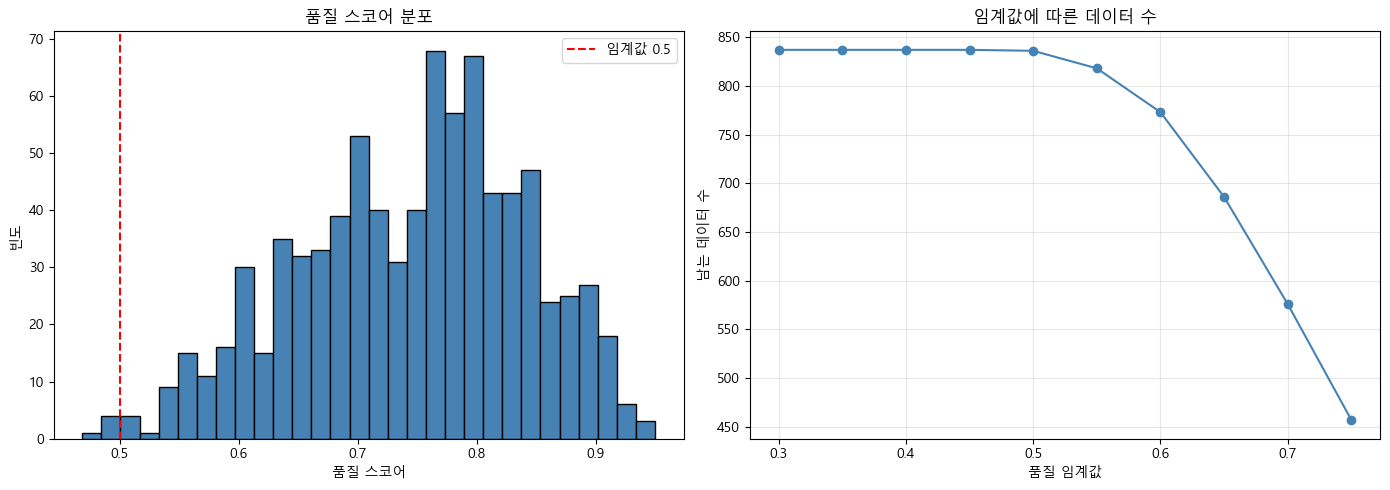


품질 필터링 (임계값 0.5):
  필터 전: 837개
  필터 후: 836개
  제거: 1개 (하위 0.1%)


In [19]:
# === 품질 점수 분포 시각화 ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 전체 분포
axes[0].hist(all_scores, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(x=0.5, color='r', linestyle='--', label='임계값 0.5')
axes[0].set_xlabel('품질 스코어')
axes[0].set_ylabel('빈도')
axes[0].set_title('품질 스코어 분포')
axes[0].legend()

# 2) 임계값별 남는 데이터 수
thresholds = np.arange(0.3, 0.8, 0.05)
remaining = [np.sum(all_scores >= t) for t in thresholds]
axes[1].plot(thresholds, remaining, 'o-', color='steelblue')
axes[1].set_xlabel('품질 임계값')
axes[1].set_ylabel('남는 데이터 수')
axes[1].set_title('임계값에 따른 데이터 수')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 임계값 적용
quality_threshold = 0.5
high_quality_idx = [i for i, s in enumerate(all_scores) if s >= quality_threshold]
data_quality = data_dedup.select(high_quality_idx)

print(f"\n품질 필터링 (임계값 {quality_threshold}):")
print(f"  필터 전: {len(data_dedup)}개")
print(f"  필터 후: {len(data_quality)}개")
removed = len(data_dedup) - len(data_quality)
print(f"  제거: {removed}개 (하위 {removed/len(data_dedup)*100:.1f}%)")

---
## 5. 언어 일관성 체크

In [20]:
# === 언어 일관성 체크 ===
# 한국어 데이터에서 영어가 과도하게 섞인 경우를 탐지
# Alpaca는 영어 데이터이므로 여기서는 원리만 보여줌

import re

def detect_language_ratio(text):
    """
    텍스트의 한글/영어/기타 비율을 계산.
    한국어 데이터 정제 시 사용.
    """
    if not text:
        return {'korean': 0, 'english': 0, 'other': 0}
    
    korean = len(re.findall(r'[가-힣]', text))
    english = len(re.findall(r'[a-zA-Z]', text))
    total = len(text.replace(' ', ''))
    
    if total == 0:
        return {'korean': 0, 'english': 0, 'other': 0}
    
    return {
        'korean': korean / total,
        'english': english / total,
        'other': 1 - (korean + english) / total,
    }

# 테스트 (한국어 데이터 시뮬레이션)
test_texts = [
    "Python으로 리스트를 정렬하는 방법을 알려주세요.",  # 정상: 한글 + 약간의 영어
    "This is entirely in English with no Korean.",  # 비정상: 영어만
    "한국어로만 작성된 완전한 문장입니다.",  # 정상: 한글만
    "Use the sort() method to arrange elements.",  # 비정상: 영어만
]

print("언어 비율 분석:")
print("=" * 60)
for text in test_texts:
    ratio = detect_language_ratio(text)
    kr_pct = ratio['korean'] * 100
    en_pct = ratio['english'] * 100
    label = "OK" if kr_pct > 30 else "경고: 한글 부족"
    preview = text[:40]
    print(f"  [{label}] 한글:{kr_pct:.0f}% 영어:{en_pct:.0f}% | {preview}...")

print("\n-> 한국어 데이터셋에서 한글 비율 30% 미만이면 제거 고려")
print("   영어 instruction에 한국어 output (혹은 반대)도 문제")

언어 비율 분석:
  [OK] 한글:72% 영어:24% | Python으로 리스트를 정렬하는 방법을 알려주세요....
  [경고: 한글 부족] 한글:0% 영어:97% | This is entirely in English with no Kore...
  [OK] 한글:94% 영어:0% | 한국어로만 작성된 완전한 문장입니다....
  [경고: 한글 부족] 한글:0% 영어:92% | Use the sort() method to arrange element...

-> 한국어 데이터셋에서 한글 비율 30% 미만이면 제거 고려
   영어 instruction에 한국어 output (혹은 반대)도 문제


---
## 6. 정제 전후 비교 시각화

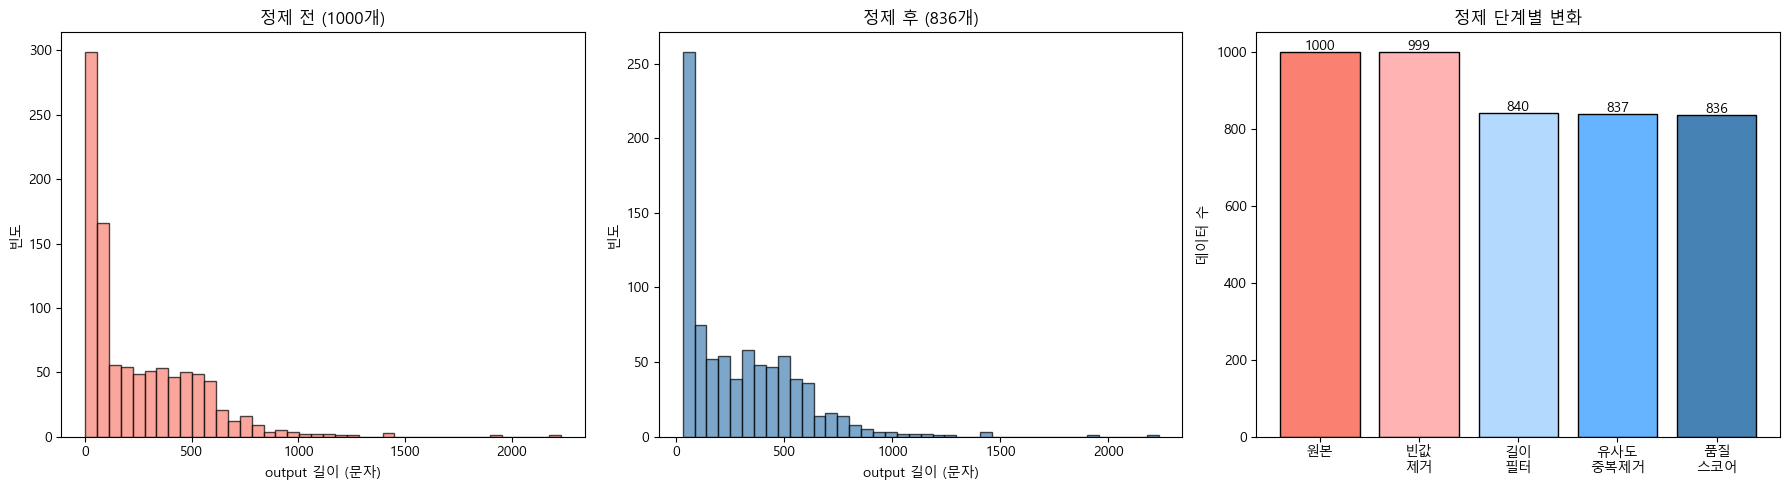


정제 요약:
  원본: 1000개
  최종: 836개
  유지율: 83.6%
  평균 output 길이: 251 -> 297


In [21]:
# === 정제 전후 비교 시각화 ===

# 정제 전/후 output 길이 수집
original_lengths = [len(data[i]['output']) for i in range(len(data))]
cleaned_lengths = [len(data_quality[i]['output']) for i in range(len(data_quality))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 정제 전 길이 분포
axes[0].hist(original_lengths, bins=40, edgecolor='black', color='salmon', alpha=0.7)
axes[0].set_xlabel('output 길이 (문자)')
axes[0].set_ylabel('빈도')
axes[0].set_title(f'정제 전 ({len(data)}개)')

# 2) 정제 후 길이 분포
axes[1].hist(cleaned_lengths, bins=40, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('output 길이 (문자)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'정제 후 ({len(data_quality)}개)')

# 3) 정제 단계별 데이터 수
stages = ['원본', '빈값\n제거', '길이\n필터', '유사도\n중복제거', '품질\n스코어']
counts = [len(data), after_empty, after_long, len(data_dedup), len(data_quality)]
colors = ['salmon', '#ffb3b3', '#b3d9ff', '#66b3ff', 'steelblue']
axes[2].bar(stages, counts, color=colors, edgecolor='black')
axes[2].set_ylabel('데이터 수')
axes[2].set_title('정제 단계별 변화')
for i, c in enumerate(counts):
    axes[2].text(i, c + 5, str(c), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 수치 요약
retention = len(data_quality) / len(data) * 100
print(f"\n정제 요약:")
print(f"  원본: {len(data)}개")
print(f"  최종: {len(data_quality)}개")
print(f"  유지율: {retention:.1f}%")
print(f"  평균 output 길이: {np.mean(original_lengths):.0f} -> {np.mean(cleaned_lengths):.0f}")

---
## 정리

| 기법 | Phase 2 | Phase 3 |
|------|---------|--------|
| **중복 제거** | 앞 100자 exact match | TF-IDF 코사인 유사도 |
| **길이 필터** | 단순 문자 수 | 양방향 (최소 + 최대) |
| **품질 판단** | 있다/없다 | 품질 스코어 (0~1) |
| **언어 체크** | 없음 | 한글/영어 비율 |
| **시각화** | 길이 분포만 | 전/후 비교 + 단계별 변화 |